## Import Library dan Load Data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1.0,1.0,1.0,1.0,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2.0,2.0,1.0,2.0,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4.0,1.0,9.0,3.0,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3.0,2.0,2.0,4.0,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3.0,3.0,1.0,4.0,Returning_Visitor,True,False


In [43]:
df.sample(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
1377,5,89.75,0,0.0,16,467.916667,0.011111,NaN,0.000000,0.0,Mar,3.0,2.0,4.0,2.0,Returning_Visitor,True,False
2344,0,0.00,0,0.0,6,227.333333,0.000000,0.013333,0.000000,0.0,May,3.0,2.0,3.0,2.0,New_Visitor,True,False
6142,0,0.00,0,0.0,4,39.950000,0.000000,0.050000,0.000000,0.0,Jul,3.0,2.0,1.0,4.0,Returning_Visitor,True,False
3807,5,73.50,1,0.0,79,5664.146032,0.045356,0.059096,2.394918,0.0,May,2.0,2.0,6.0,1.0,Returning_Visitor,False,False
312,2,7.00,0,0.0,10,75.000000,0.050000,0.110000,0.000000,0.0,Mar,2.0,2.0,1.0,1.0,Returning_Visitor,False,False


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12166 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12252 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12085 non-null  float64
 6   BounceRates              12183 non-null  float64
 7   ExitRates                12183 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12269 non-null  object 
 11  OperatingSystems         12281 non-null  float64
 12  Browser                  12281 non-null  float64
 13  Region                   12281 non-null  float64
 14  TrafficType           

In [45]:
df.shape

(12330, 18)

## Missing Value Sebelum Cleaning

In [46]:
df.isnull().sum()

Administrative               0
Administrative_Duration    164
Informational                0
Informational_Duration      78
ProductRelated               0
ProductRelated_Duration    245
BounceRates                147
ExitRates                  147
PageValues                   0
SpecialDay                   0
Month                       61
OperatingSystems            49
Browser                     49
Region                      49
TrafficType                 73
VisitorType                 73
Weekend                      0
Revenue                      0
dtype: int64

In [47]:
((df.isnull().sum() / df.shape[0]) * 100).round(2)

Administrative             0.00
Administrative_Duration    1.33
Informational              0.00
Informational_Duration     0.63
ProductRelated             0.00
ProductRelated_Duration    1.99
BounceRates                1.19
ExitRates                  1.19
PageValues                 0.00
SpecialDay                 0.00
Month                      0.49
OperatingSystems           0.40
Browser                    0.40
Region                     0.40
TrafficType                0.59
VisitorType                0.59
Weekend                    0.00
Revenue                    0.00
dtype: float64

In [48]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": ((df.isnull().sum() / df.shape[0]) * 100).round(2)
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
Administrative_Duration,164,1.33
Informational_Duration,78,0.63
ProductRelated_Duration,245,1.99
BounceRates,147,1.19
ExitRates,147,1.19
Month,61,0.49
OperatingSystems,49,0.40
Browser,49,0.40
Region,49,0.40
TrafficType,73,0.59


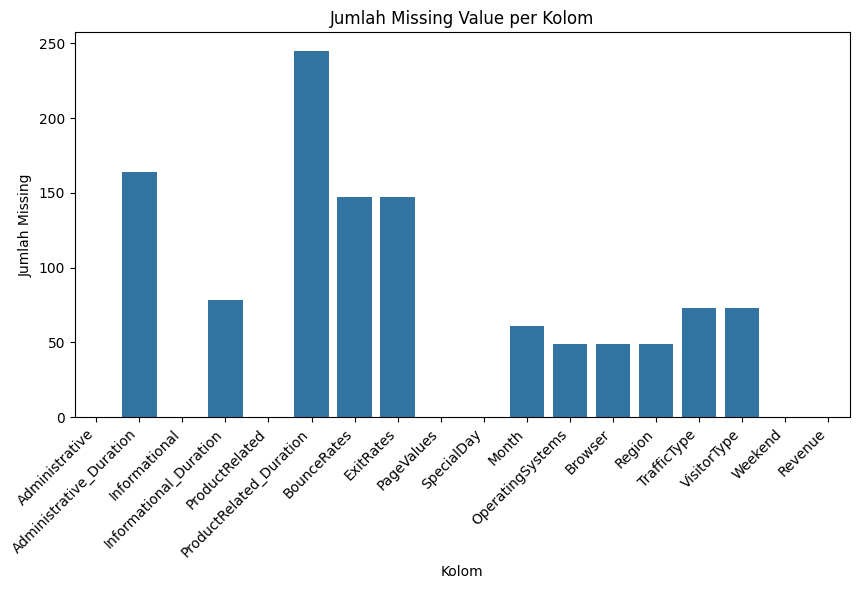

In [49]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.index,
    y=missing_summary["missing_count"]
)
plt.xticks(rotation=45, ha="right")
plt.title("Jumlah Missing Value per Kolom")
plt.ylabel("Jumlah Missing")
plt.xlabel("Kolom")
plt.show()

## Duplikat Handling

In [50]:
df.duplicated().sum()

108

In [51]:
df[df.duplicated(keep=False)].head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1.0,1.0,1.0,3.0,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3.0,2.0,3.0,3.0,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1.0,1.0,1.0,3.0,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3.0,2.0,3.0,3.0,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3.0,2.0,3.0,3.0,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1.0,1.0,1.0,1.0,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1.0,1.0,1.0,1.0,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1.0,1.0,8.0,1.0,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3.0,2.0,3.0,1.0,Returning_Visitor,False,False
341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2.0,2.0,4.0,1.0,Returning_Visitor,False,False


In [52]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [53]:
df.shape

(12222, 18)

## Cek Unique Value

In [54]:
for feature in df.select_dtypes(include="object"):
    print(feature)
    print("Unique:", df[feature].nunique(dropna=False))
    print(df[feature].value_counts(dropna=False).head(20))
    print("=" * 70)

Month
Unique: 11
Month
May     3314
Nov     2977
Mar     1861
Dec     1696
Oct      547
Sep      446
Aug      429
Jul      425
June     286
Feb      180
NaN       61
Name: count, dtype: int64
VisitorType
Unique: 4
VisitorType
Returning_Visitor    10383
New_Visitor           1685
Other                   81
NaN                     73
Name: count, dtype: int64


In [55]:
for feature in df.select_dtypes(include="bool"):
    print(feature)
    print("Unique:", df[feature].nunique(dropna=False))
    print(df[feature].value_counts(dropna=False))
    print("=" * 70)

Weekend
Unique: 2
Weekend
False    9363
True     2859
Name: count, dtype: int64
Revenue
Unique: 2
Revenue
False    10314
True      1908
Name: count, dtype: int64


In [56]:
for feature in df.select_dtypes(include=["int", "int64"]):
    print(feature)
    print("Unique:", df[feature].nunique(dropna=False))
    print(df[feature].value_counts(dropna=False).head(20))
    print("=" * 70)

Administrative
Unique: 27
Administrative
0     5660
1     1354
2     1114
3      915
4      765
5      575
6      432
7      338
8      287
9      225
10     153
11     105
12      86
13      56
14      44
15      38
16      24
17      16
18      12
19       6
Name: count, dtype: int64
Informational
Unique: 17
Informational
0     9591
1     1041
2      728
3      380
4      222
5       99
6       78
7       36
9       15
8       14
10       7
12       5
14       2
16       1
11       1
24       1
13       1
Name: count, dtype: int64
ProductRelated
Unique: 311
ProductRelated
1     520
2     459
3     458
4     404
6     396
7     391
5     382
8     370
10    330
9     317
12    313
11    308
13    289
15    270
16    260
14    251
17    226
20    225
19    218
22    213
Name: count, dtype: int64


In [57]:
for feature in df.select_dtypes(include=["float", "float64"]):
    print(feature)
    print("Unique:", df[feature].nunique(dropna=False))
    print(df[feature].value_counts(dropna=False).head(20))
    print("=" * 70)

Administrative_Duration
Unique: 3282
Administrative_Duration
0.0     5792
NaN      164
4.0       56
5.0       53
7.0       44
11.0      40
6.0       39
14.0      37
9.0       34
15.0      33
10.0      30
21.0      28
13.0      28
12.0      27
19.0      27
8.0       26
20.0      25
18.0      25
3.0       25
37.0      24
Name: count, dtype: int64
Informational_Duration
Unique: 1226
Informational_Duration
0.0     9805
NaN       78
9.0       32
10.0      26
6.0       26
7.0       24
12.0      23
13.0      22
8.0       22
16.0      22
11.0      19
17.0      18
15.0      18
5.0       17
4.0       17
14.0      17
23.0      17
18.0      17
3.0       15
21.0      14
Name: count, dtype: int64
ProductRelated_Duration
Unique: 9380
ProductRelated_Duration
0.0     631
NaN     245
17.0     21
8.0      17
11.0     16
22.0     15
15.0     15
7.0      14
12.0     14
19.0     14
13.0     14
24.0     13
14.0     13
5.0      13
59.0     12
34.0     12
25.0     12
50.0     11
36.0     11
44.0     10
Name: c

# Target Handling

In [58]:
df["Revenue"].unique()

array([False,  True])

In [59]:
df["Revenue"].value_counts(dropna=False)

Revenue
False    10314
True      1908
Name: count, dtype: int64

In [60]:
df["Revenue"].value_counts(normalize=True)

Revenue
False    0.843888
True     0.156112
Name: proportion, dtype: float64

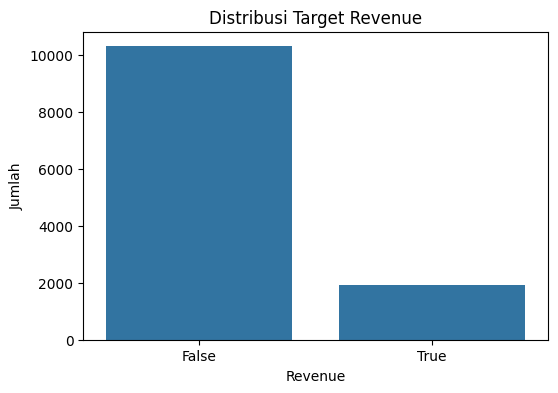

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Revenue")
plt.title("Distribusi Target Revenue")
plt.xlabel("Revenue")
plt.ylabel("Jumlah")
plt.show()

In [62]:
df["Revenue"] = df["Revenue"].astype(int)

df["Revenue"].value_counts()

Revenue
0    10314
1     1908
Name: count, dtype: int64

# Feature Type Handling

In [63]:
df["Weekend"] = df["Weekend"].astype(str)

cat_code_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]

for col in cat_code_cols:
    df[col] = df[col].astype("object")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12222 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12222 non-null  int64  
 1   Administrative_Duration  12058 non-null  float64
 2   Informational            12222 non-null  int64  
 3   Informational_Duration   12144 non-null  float64
 4   ProductRelated           12222 non-null  int64  
 5   ProductRelated_Duration  11977 non-null  float64
 6   BounceRates              12075 non-null  float64
 7   ExitRates                12075 non-null  float64
 8   PageValues               12222 non-null  float64
 9   SpecialDay               12222 non-null  float64
 10  Month                    12161 non-null  object 
 11  OperatingSystems         12173 non-null  object 
 12  Browser                  12173 non-null  object 
 13  Region                   12173 non-null  object 
 14  TrafficType              12

# Data Leakage Handling

In [64]:
Use_Page_Values = True # Kalo APInya real time diubah menjadi False karena feature PageValues sebenernya leakage

if Use_Page_Values:
    leakage_col = []
else:
    leakage_col = ["PageValues"]

leakage_col

[]

# Outlier dan Distribusi Data

In [65]:
base_num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

num_cols_check = [col for col in base_num_cols if col not in leakage_col]

num_cols_check

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay']

In [66]:
df[num_cols_check].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12222.000000,12058.000000,12222.000000,12144.000000,12222.000000,11977.000000,12075.000000,12075.000000,12222.000000,12222.000000
mean,2.335624,81.156628,0.508018,33.930267,32.002536,1206.095279,0.020560,0.041694,5.941298,0.061856
std,3.329261,178.108011,1.274870,140.279199,44.577586,1925.645944,0.045584,0.046535,18.642011,0.199541
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,191.000000,0.000000,0.014214,0.000000,0.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,607.000000,0.002930,0.025000,0.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1478.073810,0.016667,0.048758,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


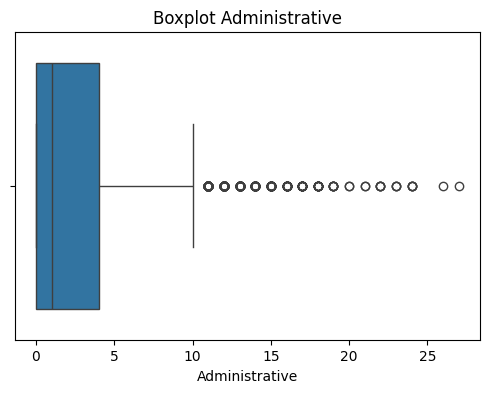

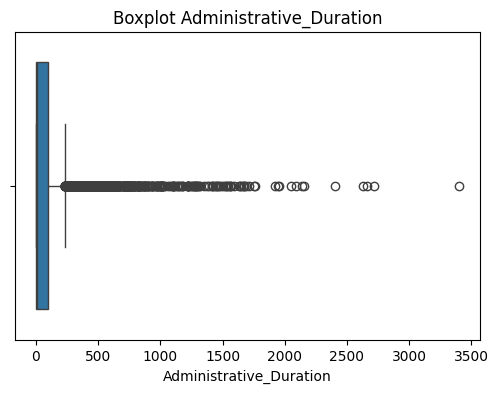

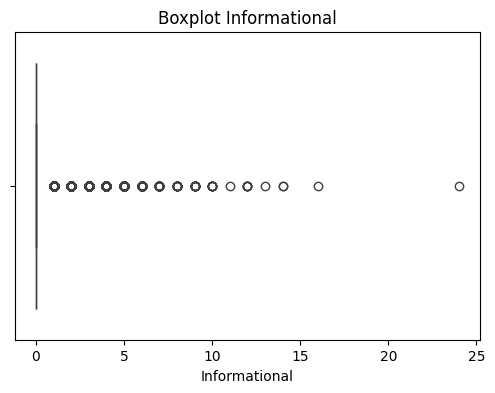

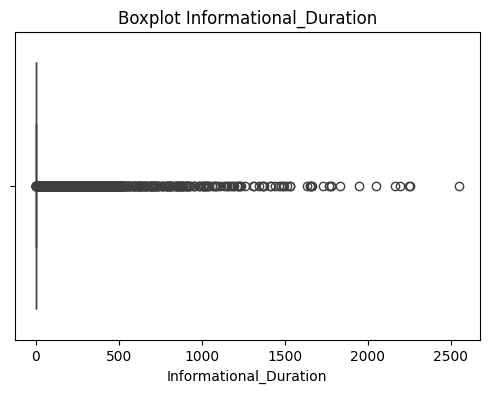

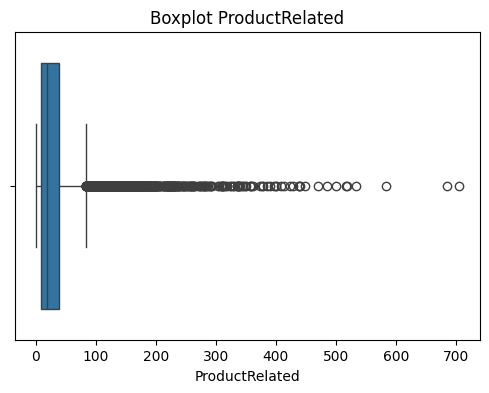

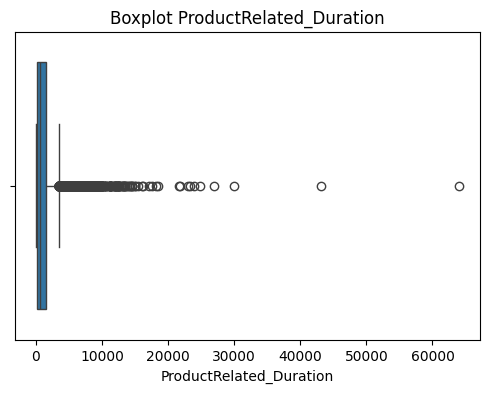

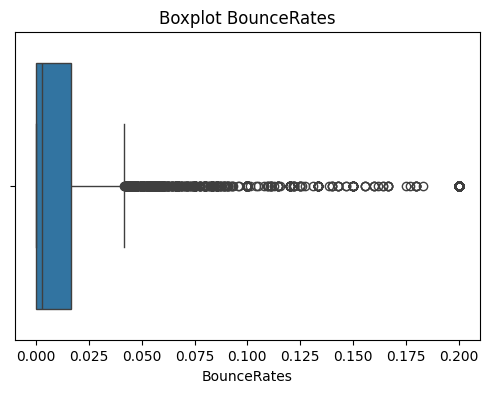

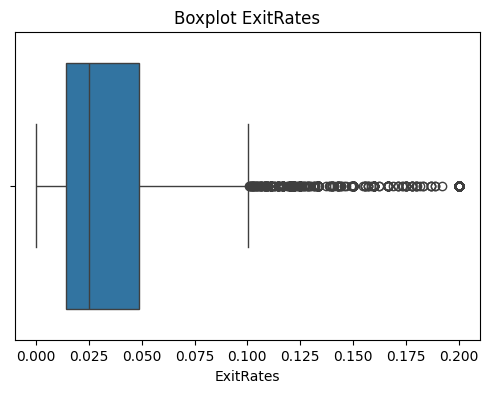

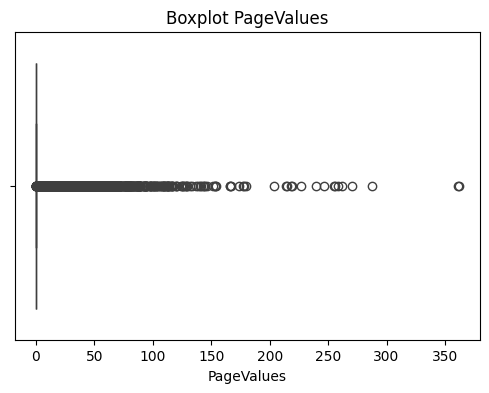

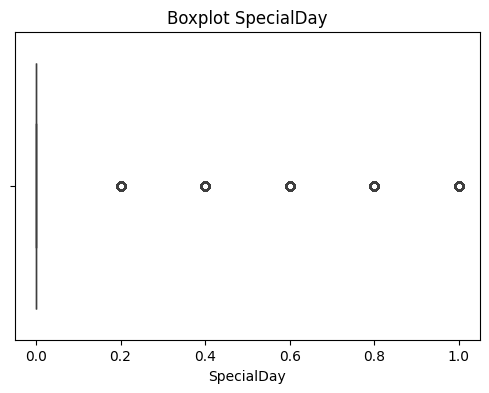

In [67]:
for col in num_cols_check:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

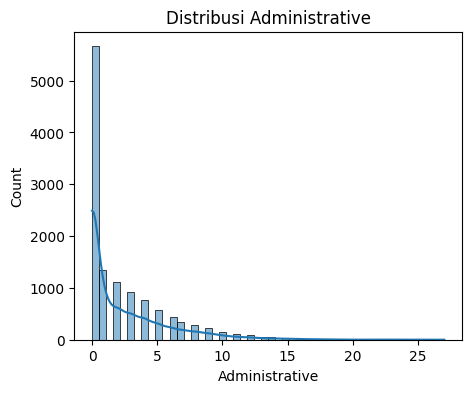

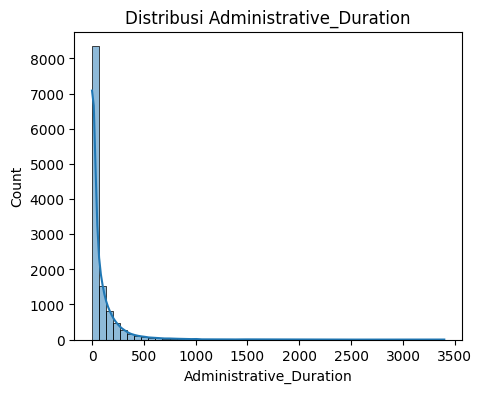

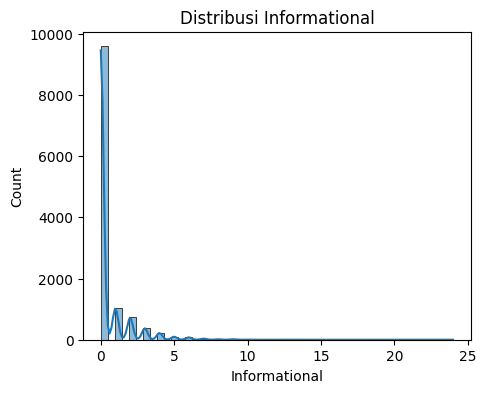

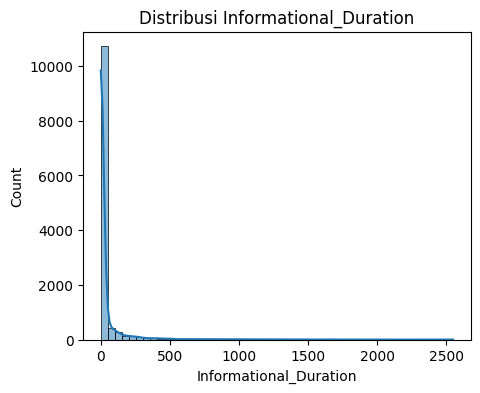

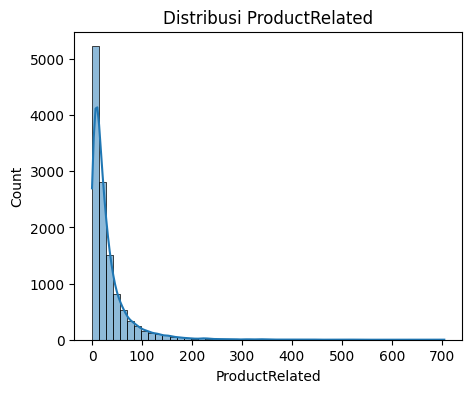

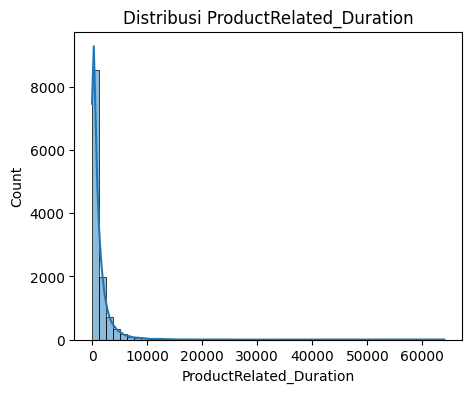

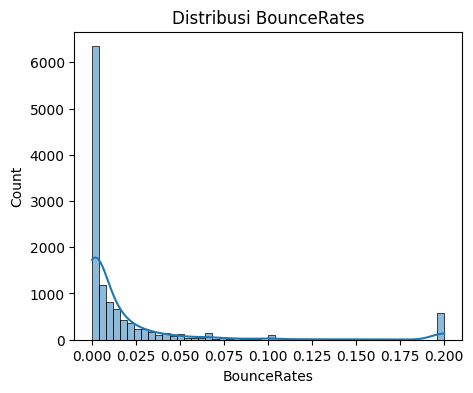

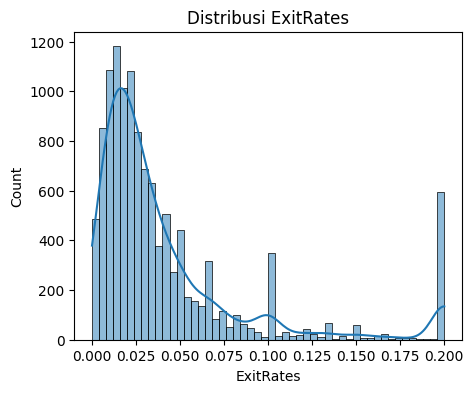

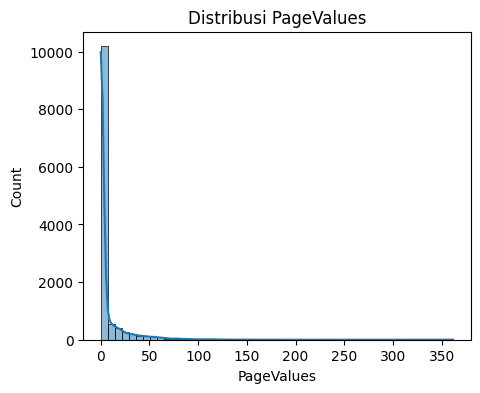

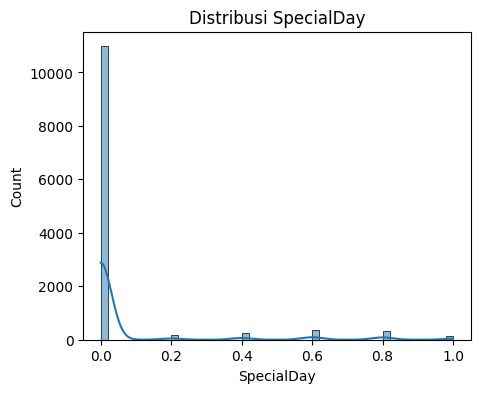

In [68]:
for col in num_cols_check:
    plt.figure(figsize=(5, 4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()

## Outlier IQR Check

In [69]:
for col in num_cols_check:
    series = pd.to_numeric(df[col], errors="coerce").dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    Lower = Q1 - 1.5 * IQR
    Upper = Q3 + 1.5 * IQR

    Outlier = df[
        (pd.to_numeric(df[col], errors="coerce") < Lower) |
        (pd.to_numeric(df[col], errors="coerce") > Upper)
    ]

    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", Lower)
    print("Upper:", Upper)
    print("Jumlah outlier:", Outlier.shape[0])
    print("=" * 70)

Administrative
Q1: 0.0
Q3: 4.0
IQR: 4.0
Lower: -6.0
Upper: 10.0
Jumlah outlier: 404
Administrative_Duration
Q1: 0.0
Q3: 93.0
IQR: 93.0
Lower: -139.5
Upper: 232.5
Jumlah outlier: 1157
Informational
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0
Jumlah outlier: 2631
Informational_Duration
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0
Jumlah outlier: 2339
ProductRelated
Q1: 8.0
Q3: 38.0
IQR: 30.0
Lower: -37.0
Upper: 83.0
Jumlah outlier: 1007
ProductRelated_Duration
Q1: 191.0
Q3: 1478.07381
IQR: 1287.07381
Lower: -1739.6107150000003
Upper: 3408.6845250000006
Jumlah outlier: 927
BounceRates
Q1: 0.0
Q3: 0.016666667
IQR: 0.016666667
Lower: -0.0250000005
Upper: 0.041666667500000004
Jumlah outlier: 1426
ExitRates
Q1: 0.014213851999999999
Q3: 0.048757716
IQR: 0.034543864
Lower: -0.037601944
Upper: 0.100573512
Jumlah outlier: 991
PageValues
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0
Jumlah outlier: 2730
SpecialDay
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0
Jumlah outlier: 1249


# Skewness Check

In [70]:
for col in num_cols_check:
    print(f"Skewness {col}: {df[col].skew():.4f}")

Skewness Administrative: 1.9489
Skewness Administrative_Duration: 5.6005
Skewness Informational: 4.0172
Skewness Informational_Duration: 7.6899
Skewness ProductRelated: 4.3345
Skewness ProductRelated_Duration: 7.2946
Skewness BounceRates: 3.1387
Skewness ExitRates: 2.2217
Skewness PageValues: 6.3553
Skewness SpecialDay: 3.2888


# Feature Engineering

In [71]:
for col in num_cols_check:
    df[col] = pd.to_numeric(df[col], errors="coerce") # untuk memastikan feature numerik 

df["TotalDuration"] = (df["Administrative_Duration"].fillna(0) + df["Informational_Duration"].fillna(0) + df["ProductRelated_Duration"].fillna(0))

df["TotalPages"] = (df["Administrative"].fillna(0) + df["Informational"].fillna(0) + df["ProductRelated"].fillna(0))

df["ProductDurationPerPage"] = df["ProductRelated_Duration"] / df["ProductRelated"].replace(0, np.nan)
df["AdminDurationPerPage"] = df["Administrative_Duration"] / df["Administrative"].replace(0, np.nan)
df["InfoDurationPerPage"] = df["Informational_Duration"] / df["Informational"].replace(0, np.nan)

df["ProductPageRatio"] = df["ProductRelated"] / df["TotalPages"].replace(0, np.nan)
df["AdminPageRatio"] = df["Administrative"] / df["TotalPages"].replace(0, np.nan)
df["InfoPageRatio"] = df["Informational"] / df["TotalPages"].replace(0, np.nan)

df["ProductDurationRatio"] = df["ProductRelated_Duration"] / df["TotalDuration"].replace(0, np.nan)
df["AdminDurationRatio"] = df["Administrative_Duration"] / df["TotalDuration"].replace(0, np.nan)
df["InfoDurationRatio"] = df["Informational_Duration"] / df["TotalDuration"].replace(0, np.nan)

df["AvgDurationPerPage"] = df["TotalDuration"] / df["TotalPages"].replace(0, np.nan)
df["ExitBounceGap"] = df["ExitRates"] - df["BounceRates"]
df["ExitBounceRatio"] = df["ExitRates"] / df["BounceRates"].replace(0, np.nan)

df["ProductEngagement"] = df["ProductRelated"] * df["ProductDurationPerPage"]
df["DurationWeightedExit"] = df["TotalDuration"] * (1 - df["ExitRates"])
df["DurationWeightedBounce"] = df["TotalDuration"] * (1 - df["BounceRates"])

month_order = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "June": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}

df["MonthNum"] = df["Month"].map(month_order)
df["IsHolidaySeason"] = df["Month"].isin(["Nov", "Dec"]).astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,AdminDurationRatio,InfoDurationRatio,AvgDurationPerPage,ExitBounceGap,ExitBounceRatio,ProductEngagement,DurationWeightedExit,DurationWeightedBounce,MonthNum,IsHolidaySeason
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,NaN,NaN,0.000000,0.00,1.0,0.000000,0.000000,0.000000,2.0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,32.000000,0.10,NaN,64.000000,57.600000,64.000000,2.0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,NaN,NaN,0.000000,0.00,1.0,0.000000,0.000000,0.000000,2.0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,1.333333,0.09,2.8,2.666667,2.293333,2.533333,2.0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,62.750000,0.03,2.5,627.500000,596.125000,614.950000,2.0,0


- Total Duration = dibuat untuk mengukur total waktu user berada di website / app. Dibuat karena biasanya user yang menghabiskan waktu lebih lama punya engagement lebih tinggi

- Total Pages = dibuat untuk mentotalkan jumlah halaman yang user kunjungi selama satu session. Dibuat untuk mengukur seberapa banyak user menjelajahi web atau app. User yang membuka banyak pages biasanya sedang eksplorasi produk untuk referensi dan membeli produk

- Feature Duration per pages = dibuat untuk menghitung rata rata durasi user per halaman. Product Duration Page untuk menghitung rata-rata waktu user di setiap halaman produk, Admin Duration Page untuk menghitung rata-rata waktu user di setiap halaman administrative, Info Duration Page untuk menghitung rata-rata waktu user di setiap halaman informasi

- Feature Page Ratio = dibuat untuk menghitung proporsi jenis halaman yang dikunjungi user

- Duration Ratio = dibuat untuk menghitung proporsi waktu user pada setiap jenis halaman (Untuk melihat di mana user menghabiskan waktu)

- Average Duration Per Page = dibuat untuk melihat apakah user hanya cepat pindah pindah page atau benar benar membaca isi halaman

- Exit Bounce Gap = Ratio antara exit rates dan bounce rates. Dibuat untuk melihat hubungan relatif antara bounce dan exit 

- Product Engagement = dibuat untuk membuat skor tentang engagement user pada produk

- Duration Weight Exit = dibuat untuk menemukan user yang lama berada di website dan user tidak menunjukan pola keluar yang tinggi, biasanya user yang ada ciri ciri tersebut punya sinyal engagment yang kuat

- Duration Weight Bounce = untuk menemukan user yang tidak langsung keluar dan lama berada di websitenya, biasanya user yang ada ciri ciri tersebut lebih engage dibandingkan user yang langsung bounce

- Month Num = Dibuat supaya model bisa menangkap dan belajar pola musiman dalam bentuk numerik, karena data dalam bentuk numerik lebih dimengerti model 

- Is Holiday Session = dibuat untuk menangkap efek musim belanja, contohnya user pada bulan tertentu punya behavior atau kebiasaan pembelian yang berbeda beda  

## Log Feature Engineering

In [72]:
log_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "TotalDuration",
    "ProductDurationPerPage",
    "AdminDurationPerPage",
    "InfoDurationPerPage",
    "AvgDurationPerPage",
    "ProductEngagement",
    "DurationWeightedExit",
    "DurationWeightedBounce"
]

for col in log_cols:
    df[col + "_log"] = np.log1p(df[col].clip(lower=0))

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Informational_Duration_log,ProductRelated_Duration_log,TotalDuration_log,ProductDurationPerPage_log,AdminDurationPerPage_log,InfoDurationPerPage_log,AvgDurationPerPage_log,ProductEngagement_log,DurationWeightedExit_log,DurationWeightedBounce_log
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,4.174387,4.174387,3.496508,NaN,NaN,3.496508,4.174387,4.070735,4.174387
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,1.299283,1.299283,0.847298,NaN,NaN,0.847298,1.299283,1.191900,1.262242
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,6.443336,6.443336,4.154969,NaN,NaN,4.154969,6.443336,6.392126,6.423166


- Log feature engineering dilakukan karena fitur-fitur durasi dan engagement pada dataset cenderung sangat skewed dan punya nilai ekstrem .Tujuannya supaya model mendapat versi fitur yang lebih stabil dan tidak terlalu dipengaruhi oleh outlier besar.

## Define Numerical dan Categorical Columns

In [73]:
num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
    "TotalDuration",
    "TotalPages",
    "ProductDurationPerPage",
    "AdminDurationPerPage",
    "InfoDurationPerPage",
    "ProductPageRatio",
    "AdminPageRatio",
    "InfoPageRatio",
    "ProductDurationRatio",
    "AdminDurationRatio",
    "InfoDurationRatio",
    "AvgDurationPerPage",
    "ExitBounceGap",
    "ExitBounceRatio",
    "ProductEngagement",
    "DurationWeightedExit",
    "DurationWeightedBounce",
    "Administrative_Duration_log",
    "Informational_Duration_log",
    "ProductRelated_Duration_log",
    "TotalDuration_log",
    "ProductDurationPerPage_log",
    "AdminDurationPerPage_log",
    "InfoDurationPerPage_log",
    "AvgDurationPerPage_log",
    "ProductEngagement_log",
    "DurationWeightedExit_log",
    "DurationWeightedBounce_log",
    "MonthNum",
    "IsHolidaySeason"
]

if Use_Page_Values:
    num_cols.append("PageValues")

cat_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

num_cols = [col for col in num_cols if col not in leakage_col]
cat_cols = [col for col in cat_cols if col not in leakage_col]

num_cols, cat_cols

(['Administrative',
  'Administrative_Duration',
  'Informational',
  'Informational_Duration',
  'ProductRelated',
  'ProductRelated_Duration',
  'BounceRates',
  'ExitRates',
  'SpecialDay',
  'TotalDuration',
  'TotalPages',
  'ProductDurationPerPage',
  'AdminDurationPerPage',
  'InfoDurationPerPage',
  'ProductPageRatio',
  'AdminPageRatio',
  'InfoPageRatio',
  'ProductDurationRatio',
  'AdminDurationRatio',
  'InfoDurationRatio',
  'AvgDurationPerPage',
  'ExitBounceGap',
  'ExitBounceRatio',
  'ProductEngagement',
  'DurationWeightedExit',
  'DurationWeightedBounce',
  'Administrative_Duration_log',
  'Informational_Duration_log',
  'ProductRelated_Duration_log',
  'TotalDuration_log',
  'ProductDurationPerPage_log',
  'AdminDurationPerPage_log',
  'InfoDurationPerPage_log',
  'AvgDurationPerPage_log',
  'ProductEngagement_log',
  'DurationWeightedExit_log',
  'DurationWeightedBounce_log',
  'MonthNum',
  'IsHolidaySeason',
  'PageValues'],
 ['Month',
  'OperatingSystems',
  'B

In [74]:
df[num_cols + cat_cols + ["Revenue"]].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,TotalDuration,...,IsHolidaySeason,PageValues,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.000000,...,0,0.0,Feb,1.0,1.0,1.0,1.0,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,64.000000,...,0,0.0,Feb,2.0,2.0,1.0,2.0,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.000000,...,0,0.0,Feb,4.0,1.0,9.0,3.0,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,2.666667,...,0,0.0,Feb,3.0,2.0,2.0,4.0,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,627.500000,...,0,0.0,Feb,3.0,3.0,1.0,4.0,Returning_Visitor,True,0


# Final Check Sebelum Modeling

In [75]:
df[num_cols + cat_cols + ["Revenue"]].isnull().sum()

Administrative                    0
Administrative_Duration         164
Informational                     0
Informational_Duration           78
ProductRelated                    0
ProductRelated_Duration         245
BounceRates                     147
ExitRates                       147
SpecialDay                        0
TotalDuration                     0
TotalPages                        0
ProductDurationPerPage          283
AdminDurationPerPage           5824
InfoDurationPerPage            9669
ProductPageRatio                  6
AdminPageRatio                    6
InfoPageRatio                     6
ProductDurationRatio            842
AdminDurationRatio              873
InfoDurationRatio               792
AvgDurationPerPage                6
ExitBounceGap                   292
ExitBounceRatio                5681
ProductEngagement               283
DurationWeightedExit            147
DurationWeightedBounce          147
Administrative_Duration_log     164
Informational_Duration_log  

In [76]:
df["Revenue"].value_counts(normalize=True)

Revenue
0    0.843888
1    0.156112
Name: proportion, dtype: float64

# Split Train dan Test

In [77]:
x = df[num_cols + cat_cols]
y = df["Revenue"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2, stratify=y
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((9777, 47), (2445, 47), (9777,), (2445,))

# Pipeline

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

num_pipeline = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy="median")),
    ("Scaler", RobustScaler())
])

cat_pipeline = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("Encoding", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        min_frequency=10
    ))
])

preprocessor = ColumnTransformer([
    ("Num", num_pipeline, num_cols),
    ("Cat", cat_pipeline, cat_cols)
])

# Model Baseline dan Cross Validation

In [79]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metric = "average_precision" 

## Model 1 Logistic Regression

In [80]:
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

scores_lr = cross_val_score(
    model_lr,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Logistic Regression PR-AUC score : {scores_lr}")
print(f"Mean Logistic Regression PR-AUC  : {scores_lr.mean()}")

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

Logistic Regression PR-AUC score : [0.65428124 0.6568897  0.633069   0.64073936 0.67360276]
Mean Logistic Regression PR-AUC  : 0.6517164133070698


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Logistic Regression Hyperparameter Tuning

In [81]:
param_grid_lr = {
    "Model__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    "Model__penalty": ["l1", "l2"],
    "Model__solver": ["liblinear", "saga"]
}

search_lr = RandomizedSearchCV(
    estimator=model_lr,
    param_distributions=param_grid_lr,
    n_iter=14,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_lr.fit(x_train, y_train)

print("Best Params LR :", search_lr.best_params_)
print("Best CV PR-AUC LR :", search_lr.best_score_)

best_lr = search_lr.best_estimator_

Best Params LR : {'Model__solver': 'liblinear', 'Model__penalty': 'l1', 'Model__C': 0.01}
Best CV PR-AUC LR : 0.6643742040376323


## Model 2 Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

scores_rf = cross_val_score(
    model_rf,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Random Forest CV PR-AUC : {scores_rf}")
print(f"Mean Random Forest CV PR-AUC : {scores_rf.mean()}")

Random Forest CV PR-AUC : [0.71468228 0.69819587 0.72419589 0.73033635 0.73374742]
Mean Random Forest CV PR-AUC : 0.7202315610910082


## Random Forest Hyperparameter Tuning

In [83]:
param_grid_rf = {
    "Model__n_estimators": [300, 500, 700],
    "Model__max_depth": [8, 10, 12, 15, 20, None],
    "Model__min_samples_split": [5, 10, 20, 30],
    "Model__min_samples_leaf": [2, 3, 4, 6, 8],
    "Model__max_features": ["sqrt", "log2", 0.4, 0.6],
    "Model__class_weight": ["balanced", "balanced_subsample"]
}

search_rf = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_grid_rf,
    n_iter=25,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_rf.fit(x_train, y_train)

print("Best Params RF :", search_rf.best_params_)
print("Best CV PR-AUC RF :", search_rf.best_score_)

best_rf = search_rf.best_estimator_

Best Params RF : {'Model__n_estimators': 300, 'Model__min_samples_split': 10, 'Model__min_samples_leaf': 8, 'Model__max_features': 0.6, 'Model__max_depth': 15, 'Model__class_weight': 'balanced_subsample'}
Best CV PR-AUC RF : 0.7537763179512591


## Model 3 Extra Trees

In [84]:
from sklearn.ensemble import ExtraTreesClassifier

model_et = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

scores_et = cross_val_score(
    model_et,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Extra Trees CV PR-AUC : {scores_et}")
print(f"Mean Extra Trees CV PR-AUC : {scores_et.mean()}")

Extra Trees CV PR-AUC : [0.60888345 0.60165469 0.61972124 0.61708636 0.63659558]
Mean Extra Trees CV PR-AUC : 0.6167882639410343


## Extra Trees Hyperparameter Tuning

In [85]:
param_grid_et = {
    "Model__n_estimators": [300, 500, 700],
    "Model__max_depth": [10, 15, 20, 25, None],
    "Model__min_samples_split": [5, 10, 20],
    "Model__min_samples_leaf": [2, 3, 4, 6],
    "Model__max_features": ["sqrt", "log2", 0.4, 0.6],
    "Model__class_weight": ["balanced", "balanced_subsample"]
}

search_et = RandomizedSearchCV(
    estimator=model_et,
    param_distributions=param_grid_et,
    n_iter=25,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_et.fit(x_train, y_train)

print("Best Params ET :", search_et.best_params_)
print("Best CV PR-AUC ET :", search_et.best_score_)

best_et = search_et.best_estimator_

Best Params ET : {'Model__n_estimators': 700, 'Model__min_samples_split': 5, 'Model__min_samples_leaf': 3, 'Model__max_features': 0.6, 'Model__max_depth': None, 'Model__class_weight': 'balanced'}
Best CV PR-AUC ET : 0.7391226437493196


## Model 4 Gradient Boosting

In [86]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", GradientBoostingClassifier(random_state=42))
])

scores_gb = cross_val_score(
    model_gb,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Gradient Boosting CV PR-AUC : {scores_gb}")
print(f"Mean Gradient Boosting CV PR-AUC : {scores_gb.mean()}")

Gradient Boosting CV PR-AUC : [0.74841869 0.72842303 0.74591066 0.74510784 0.76818089]
Mean Gradient Boosting CV PR-AUC : 0.7472082204533547


## Gradient Boosting Hyperparameter Tuning

In [87]:
param_grid_gb = {
    "Model__n_estimators": [100, 200, 300, 400],
    "Model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "Model__max_depth": [2, 3, 4, 5],
    "Model__min_samples_split": [2, 5, 10, 20],
    "Model__min_samples_leaf": [1, 2, 4, 8],
    "Model__subsample": [0.7, 0.8, 0.9, 1.0]
}

search_gb = RandomizedSearchCV(
    estimator=model_gb,
    param_distributions=param_grid_gb,
    n_iter=25,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_gb.fit(x_train, y_train)

print("Best Params GB :", search_gb.best_params_)
print("Best CV PR-AUC GB :", search_gb.best_score_)

best_gb = search_gb.best_estimator_

Best Params GB : {'Model__subsample': 0.7, 'Model__n_estimators': 400, 'Model__min_samples_split': 5, 'Model__min_samples_leaf': 2, 'Model__max_depth': 5, 'Model__learning_rate': 0.01}
Best CV PR-AUC GB : 0.7540697221155033


## Model 5 Hist Gradient Boosting

In [88]:
from sklearn.ensemble import HistGradientBoostingClassifier

model_hgb = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", HistGradientBoostingClassifier(random_state=42))
])

scores_hgb = cross_val_score(
    model_hgb,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Hist Gradient Boosting CV PR-AUC : {scores_hgb}")
print(f"Mean Hist Gradient Boosting CV PR-AUC : {scores_hgb.mean()}")

Hist Gradient Boosting CV PR-AUC : [0.74119332 0.72186189 0.75239763 0.75014197 0.76500371]
Mean Hist Gradient Boosting CV PR-AUC : 0.7461197044609774


## Hist Gradient Boosting Hyperparameter Tuning

In [89]:
param_grid_hgb = {
    "Model__max_iter": [100, 200, 300, 400],
    "Model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "Model__max_leaf_nodes": [15, 31, 45, 63],
    "Model__min_samples_leaf": [10, 20, 30, 50],
    "Model__l2_regularization": [0, 0.01, 0.05, 0.1, 0.5]
}

search_hgb = RandomizedSearchCV(
    estimator=model_hgb,
    param_distributions=param_grid_hgb,
    n_iter=25,
    scoring=scoring_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_hgb.fit(x_train, y_train)

print("Best Params HGB :", search_hgb.best_params_)
print("Best CV PR-AUC HGB :", search_hgb.best_score_)

best_hgb = search_hgb.best_estimator_

Best Params HGB : {'Model__min_samples_leaf': 30, 'Model__max_leaf_nodes': 15, 'Model__max_iter': 300, 'Model__learning_rate': 0.01, 'Model__l2_regularization': 0.01}
Best CV PR-AUC HGB : 0.7584517878540471


# Soft Voting Model

In [90]:
from sklearn.ensemble import VotingClassifier

model_voting = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("Model", VotingClassifier(
        estimators=[
            ("lr", best_lr.named_steps["Model"]),
            ("rf", best_rf.named_steps["Model"]),
            ("et", best_et.named_steps["Model"]),
            ("gb", best_gb.named_steps["Model"]),
            ("hgb", best_hgb.named_steps["Model"])
        ],
        voting="soft",
        n_jobs=-1
    ))
])

scores_voting = cross_val_score(
    model_voting,
    x_train,
    y_train,
    cv=cv,
    scoring=scoring_metric,
    error_score="raise"
)

print(f"Soft Voting CV PR-AUC : {scores_voting}")
print(f"Mean Soft Voting CV PR-AUC : {scores_voting.mean()}")

model_voting.fit(x_train, y_train)
best_voting = model_voting

Soft Voting CV PR-AUC : [0.75606883 0.73333445 0.75154582 0.75714726 0.78249496]
Mean Soft Voting CV PR-AUC : 0.7561182622628888


# Perbandingan Semua Model

In [91]:
results = {
    "Logistic Regression": search_lr.best_score_,
    "Random Forest": search_rf.best_score_,
    "Extra Trees": search_et.best_score_,
    "Gradient Boosting": search_gb.best_score_,
    "Hist Gradient Boosting": search_hgb.best_score_,
    "Soft Voting": scores_voting.mean()
}

for k, v in results.items():
    print(f"{k}: {v:.6f}")

Logistic Regression: 0.664374
Random Forest: 0.753776
Extra Trees: 0.739123
Gradient Boosting: 0.754070
Hist Gradient Boosting: 0.758452
Soft Voting: 0.756118


In [92]:
summary_df = pd.DataFrame({
    "model": list(results.keys()),
    "cv_pr_auc": list(results.values())
}).sort_values("cv_pr_auc", ascending=False)

summary_df

,model,cv_pr_auc
4,Hist Gradient Boosting,0.758452
5,Soft Voting,0.756118
3,Gradient Boosting,0.754070
1,Random Forest,0.753776
2,Extra Trees,0.739123
0,Logistic Regression,0.664374


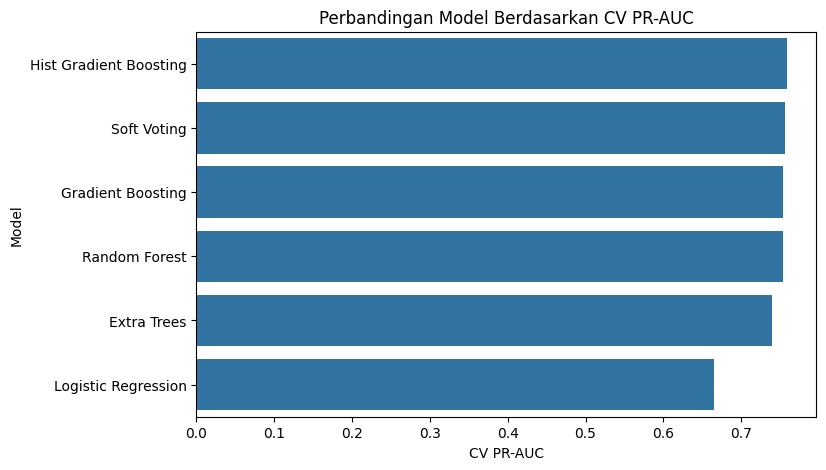

In [93]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="cv_pr_auc", y="model")
plt.title("Perbandingan Model Berdasarkan CV PR-AUC")
plt.xlabel("CV PR-AUC")
plt.ylabel("Model")
plt.show()

# Model Terbaik Untuk Evaluasi

In [94]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    accuracy_score
)

model_mapping = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Extra Trees": best_et,
    "Gradient Boosting": best_gb,
    "Hist Gradient Boosting": best_hgb,
    "Soft Voting": best_voting
}

best_model_name = max(results, key=results.get)
best_model = model_mapping[best_model_name]

print("Best Model dari CV :", best_model_name)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("Test PR-AUC   :", average_precision_score(y_test, y_proba))
print("Brier Score   :", brier_score_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Model dari CV : Hist Gradient Boosting
Test Accuracy : 0.9051124744376278
Test ROC-AUC  : 0.9326522144084379
Test PR-AUC   : 0.7414679221601179
Brier Score   : 0.07068416272944808
[[1972   91]
 [ 141  241]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2063
           1       0.73      0.63      0.68       382

    accuracy                           0.91      2445
   macro avg       0.83      0.79      0.81      2445
weighted avg       0.90      0.91      0.90      2445



## Confusion Matrix

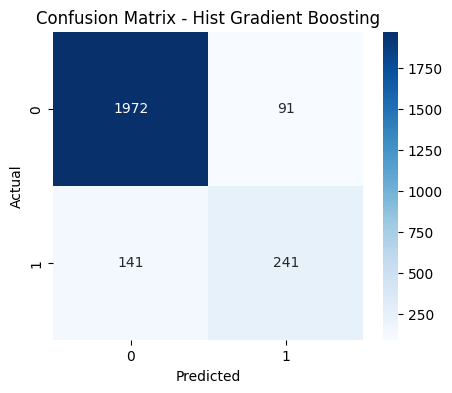

In [95]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve

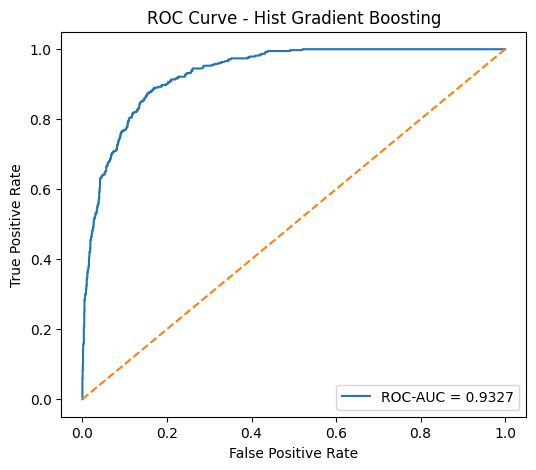

In [96]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Precision Recall Curve

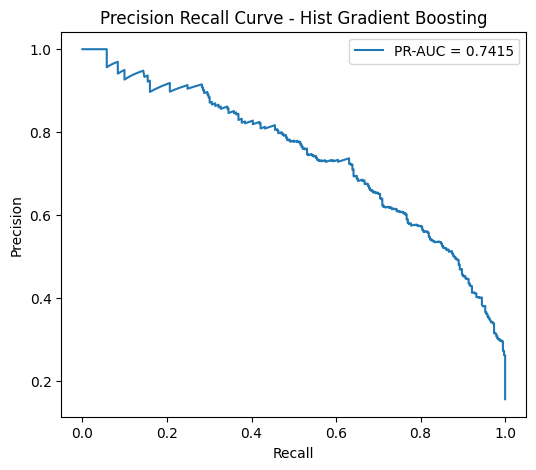

In [97]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_proba):.4f}")
plt.title(f"Precision Recall Curve - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## Threshold Tuning

In [98]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1
0,0.05,0.311667,0.979058,0.472819
1,0.06,0.333035,0.973822,0.496331
2,0.07,0.367306,0.952880,0.530226
3,0.08,0.402700,0.937173,0.563336
4,0.09,0.429268,0.921466,0.585691
...,...,...,...,...
81,0.86,0.944444,0.133508,0.233945
82,0.87,0.936170,0.115183,0.205128
83,0.88,0.928571,0.102094,0.183962
84,0.89,0.947368,0.094241,0.171429


In [99]:
best_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
print("Best threshold berdasarkan F1 :", best_threshold)

y_pred_best_threshold = (y_proba >= best_threshold).astype(int)

print("Confusion Matrix - Best Threshold")
print(confusion_matrix(y_test, y_pred_best_threshold))
print(classification_report(y_test, y_pred_best_threshold))

Best threshold berdasarkan F1 : 0.49000000000000005
Confusion Matrix - Best Threshold
[[1969   94]
 [ 139  243]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2063
           1       0.72      0.64      0.68       382

    accuracy                           0.90      2445
   macro avg       0.83      0.80      0.81      2445
weighted avg       0.90      0.90      0.90      2445



# Save Model Untuk Deployment

In [109]:
import joblib

model = "./artifacts/online_shoppers_model.pkl"
joblib.dump(best_model, model)

print("Model berhasil disimpan sebagai:", model)
print("Best threshold:", best_threshold)

Model berhasil disimpan sebagai: ./artifacts/online_shoppers_model.pkl
Best threshold: 0.49000000000000005


In [110]:
import joblib
import numpy as np

# SAVE TRAINED MODEL

joblib.dump(model, "online_shoppers_model.pkl")

print("Model saved as online_shoppers_model.pkl")


# SAVE MODEL COLUMNS

model_columns = x.columns.tolist()

joblib.dump(model_columns, "model_columns.pkl")

print("Model columns saved as model_columns.pkl")

# SAVE CLASSIFICATION THRESHOLD

# Default threshold
threshold = 0.5

joblib.dump(threshold, "threshold.pkl")

print("Threshold saved as threshold.pkl")


# VERIFY SAVED FILES

loaded_model = joblib.load("online_shoppers_model.pkl")
loaded_columns = joblib.load("model_columns.pkl")
loaded_threshold = joblib.load("threshold.pkl")

print("\n=== Verification ===")
print("Model loaded successfully")
print("Columns:", loaded_columns)
print("Threshold:", loaded_threshold)

Model saved as online_shoppers_model.pkl
Model columns saved as model_columns.pkl
Threshold saved as threshold.pkl

=== Verification ===
Model loaded successfully
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'TotalDuration', 'TotalPages', 'ProductDurationPerPage', 'AdminDurationPerPage', 'InfoDurationPerPage', 'ProductPageRatio', 'AdminPageRatio', 'InfoPageRatio', 'ProductDurationRatio', 'AdminDurationRatio', 'InfoDurationRatio', 'AvgDurationPerPage', 'ExitBounceGap', 'ExitBounceRatio', 'ProductEngagement', 'DurationWeightedExit', 'DurationWeightedBounce', 'Administrative_Duration_log', 'Informational_Duration_log', 'ProductRelated_Duration_log', 'TotalDuration_log', 'ProductDurationPerPage_log', 'AdminDurationPerPage_log', 'InfoDurationPerPage_log', 'AvgDurationPerPage_log', 'ProductEngagement_log', 'DurationWeightedExit_log', 'DurationWeightedBou

## Contoh Input Untuk Deployment

In [111]:
sample_input = x_test.head(5)
sample_input

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,TotalDuration,...,MonthNum,IsHolidaySeason,PageValues,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
4087,0,0.0,0,0.0,20,769.500000,0.000000,0.052000,0.0,769.500000,...,5.0,0,0.0,May,2.0,2.0,1.0,13.0,Returning_Visitor,False
4943,0,0.0,0,0.0,36,1851.833333,0.008333,0.040741,0.4,1851.833333,...,5.0,0,0.0,May,4.0,1.0,2.0,4.0,Returning_Visitor,False
685,0,0.0,0,0.0,12,167.222222,0.000000,0.001667,0.0,167.222222,...,3.0,0,0.0,Mar,3.0,2.0,1.0,3.0,Returning_Visitor,True
6074,8,131.0,0,0.0,32,5330.633333,0.008108,0.051351,0.0,5461.633333,...,8.0,0,0.0,Aug,2.0,2.0,2.0,1.0,Returning_Visitor,True
2228,1,135.5,0,0.0,50,824.666667,0.000000,0.003922,0.0,960.166667,...,5.0,0,0.0,May,2.0,2.0,2.0,4.0,Returning_Visitor,False


In [112]:
loaded_model = joblib.load(model)

sample_prediction = loaded_model.predict(sample_input)
sample_probability = loaded_model.predict_proba(sample_input)[:, 1]

print("Prediction:", sample_prediction)
print("Probability Revenue True:", sample_probability)

Prediction: [0 0 0 0 0]
Probability Revenue True: [0.00828572 0.00828572 0.0083251  0.07181728 0.00899037]


In [113]:
sample_result = sample_input.copy()
sample_result["Actual_Revenue"] = y_test.loc[sample_input.index].values
sample_result["Prediction"] = sample_prediction
sample_result["Probability_Revenue_True"] = sample_probability
sample_result

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,TotalDuration,...,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Actual_Revenue,Prediction,Probability_Revenue_True
4087,0,0.0,0,0.0,20,769.500000,0.000000,0.052000,0.0,769.500000,...,May,2.0,2.0,1.0,13.0,Returning_Visitor,False,0,0,0.008286
4943,0,0.0,0,0.0,36,1851.833333,0.008333,0.040741,0.4,1851.833333,...,May,4.0,1.0,2.0,4.0,Returning_Visitor,False,0,0,0.008286
685,0,0.0,0,0.0,12,167.222222,0.000000,0.001667,0.0,167.222222,...,Mar,3.0,2.0,1.0,3.0,Returning_Visitor,True,0,0,0.008325
6074,8,131.0,0,0.0,32,5330.633333,0.008108,0.051351,0.0,5461.633333,...,Aug,2.0,2.0,2.0,1.0,Returning_Visitor,True,0,0,0.071817
2228,1,135.5,0,0.0,50,824.666667,0.000000,0.003922,0.0,960.166667,...,May,2.0,2.0,2.0,4.0,Returning_Visitor,False,0,0,0.008990
